In [1]:
library(ggplot2)
library(pheatmap)
library(plyr)
library(viridis)
library(tidyr)
library(dplyr)
library(ggrepel)

Loading required package: viridisLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggrepel’ was built under R version 4.2.3”


In [2]:
var = 'MEF2'

In [3]:
dmso <- read.table(paste0(var, '/', var, '_motifs_DMSO_matrix.mat.gz'),skip=1, header=F)
h151 <- read.table(paste0(var, '/', var, '_motifs_H151_matrix.mat.gz'),skip=1, header=F)

dmso[,1:6] <- NULL
h151[,1:6] <- NULL

dmso <- colMeans(dmso, na.rm = TRUE)
h151 <- colMeans(h151, na.rm = TRUE)

peaks <- cbind(h151, dmso)
colnames(peaks) <- c('H151', 'DMSO')

peaks <- as.data.frame(peaks)

peaks$bin <- (-14.5:14.5)

In [4]:
sum_H151 <- sum(peaks$H151[11:20], na.rm = TRUE)
sum_DMSO <- sum(peaks$DMSO[11:20], na.rm = TRUE)

result <- sum_H151 / sum_DMSO

print(result)

wilcox.test(peaks$H151[11:20], peaks$DMSO[11:20])

[1] 1.2406



	Wilcoxon rank sum exact test

data:  peaks$H151[11:20] and peaks$DMSO[11:20]
W = 81, p-value = 0.01854
alternative hypothesis: true location shift is not equal to 0


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


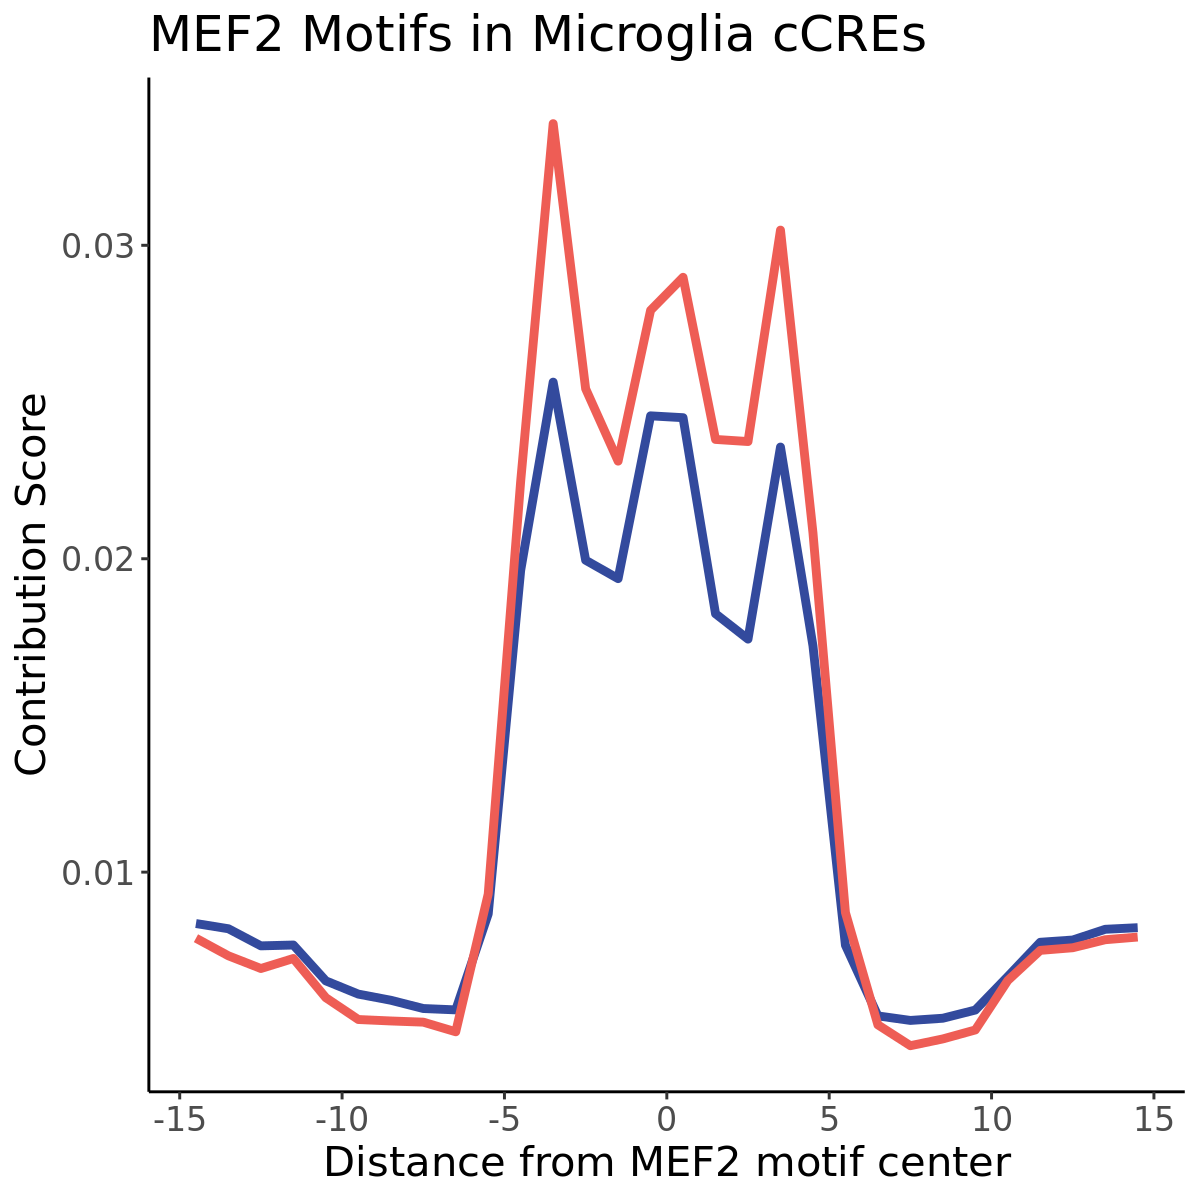

In [5]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 200)
plot1 <- ggplot(data = peaks, aes(x = bin, y = `DMSO`)) +
  geom_line(aes(y = `DMSO`), color = "#334A9D", size = 1.5) +  # Line for 'All' column in blue
  geom_line(aes(y = `H151`), color = "#EE5D55", size = 1.5) +  # Line for 'nrf1' column in red
  labs(x = paste0("Distance from ", var, " motif center"), y = "Contribution Score", title = paste0(var, " Motifs in Microglia cCREs")) +
  scale_x_continuous(breaks = seq(-15, 15, by = 5)) +  # Adjust x-axis breaks as needed
  scale_y_continuous(breaks = seq(0.0, max(peaks$`DMSO`, peaks$`H151`), by = 0.01)) +
  theme_classic() + theme(text = element_text(size = 15))
plot1

ggsave(paste0("../../../../ggsave_plots/chrombpnet_contribution_score_averages_", var, ".pdf"), plot=plot1, font='Helvetica', device="pdf", width=6, height=6)

In [62]:
#all motifs

In [63]:
all_motifs <- read.table('all_motif_sites.txt',header=T)

In [64]:
motifs <- unique(gsub("/", "_", all_motifs$motif_cluster))
motifs <- setdiff(motifs, "motif_cluster")

In [68]:
vol_val <- data.frame(fold = numeric(),
                      p_value = numeric(),
                      motif = character(),
                      stringsAsFactors = FALSE)

for (var in motifs) {
    
dmso <- read.table(paste0('all_motifs/', var, '/', var, '_motifs_DMSO_matrix.mat.gz'),skip=1, header=F)
h151 <- read.table(paste0('all_motifs/', var, '/', var, '_motifs_H151_matrix.mat.gz'),skip=1, header=F)

dmso[,1:6] <- NULL
h151[,1:6] <- NULL

dmso <- colMeans(dmso, na.rm = TRUE)
h151 <- colMeans(h151, na.rm = TRUE)

peaks <- cbind(h151, dmso)
colnames(peaks) <- c('H151', 'DMSO')

peaks <- as.data.frame(peaks)

peaks$bin <- (-14.5:14.5)
    
sum_H151 <- sum(peaks$H151[11:20], na.rm = TRUE)
sum_DMSO <- sum(peaks$DMSO[11:20], na.rm = TRUE)

fold <- sum_H151 / sum_DMSO
test <- wilcox.test(peaks$H151[11:20], peaks$DMSO[11:20])


 vol_val <- rbind(vol_val, data.frame(fold = fold,
                                       p_value = test$p.value,
                                       motif = var))
    
    }

Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H151[11:20], peaks$DMSO[11:20]):
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(peaks$H15

Warning message:
“ggrepel: 22 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


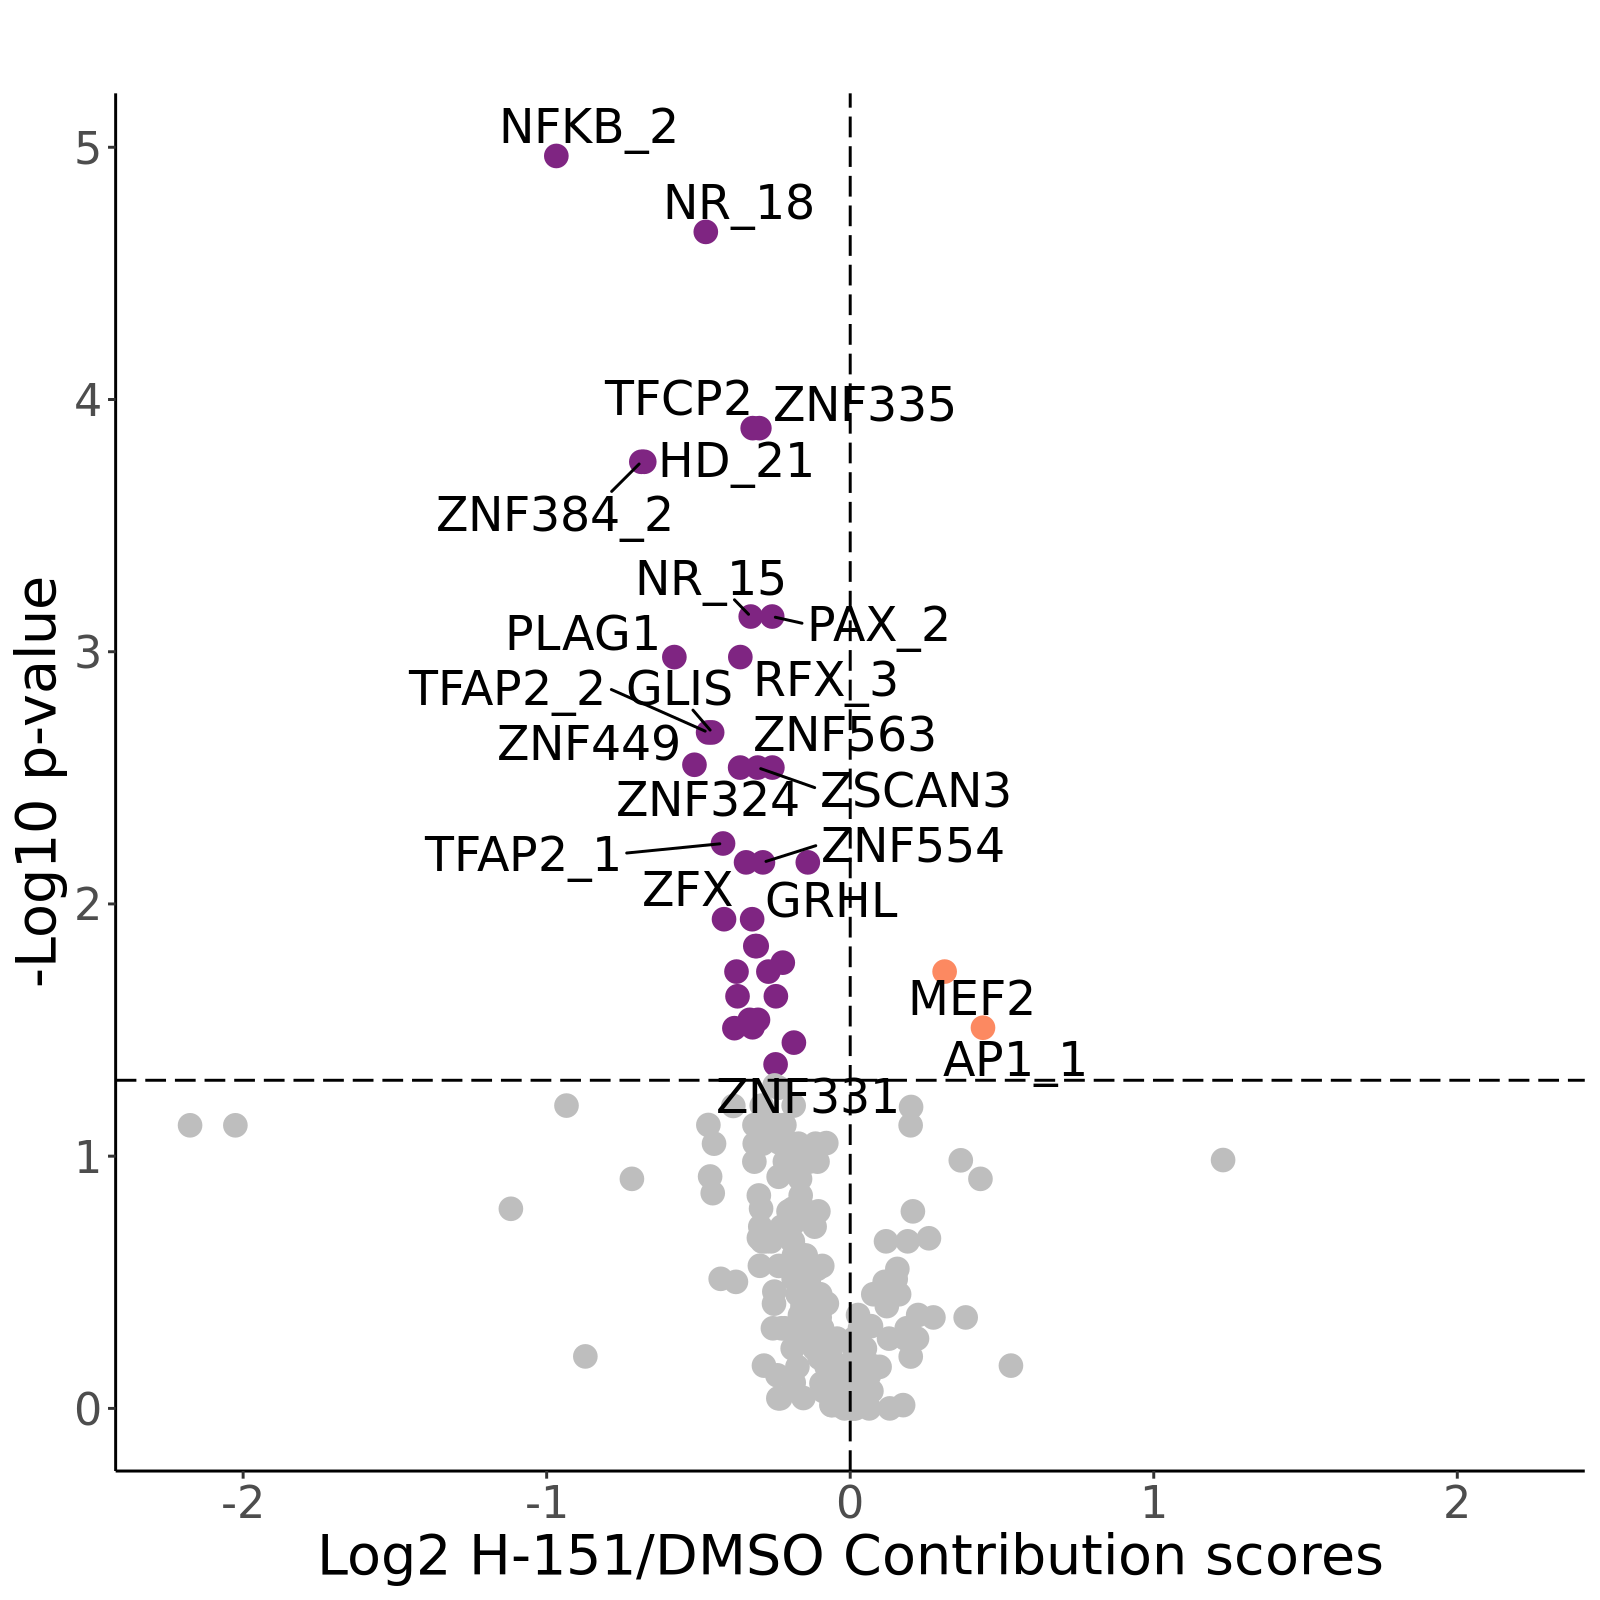

In [69]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

vol_val$color <- ifelse(vol_val$p_value < 0.05 & vol_val$fold > 1, "#FC8961",
                        ifelse(vol_val$p_value < 0.05 & vol_val$fold < 1, "#7F2582", "grey"))

scatter1 <- ggplot(data = vol_val, aes(x = log2(fold), y = -log10(p_value))) +
  geom_point(aes(color = color), size = 3.5) +
  geom_text_repel(aes(label = motif), size = 6, max.overlaps = 10, 
                   data = subset(vol_val, p_value < 0.05)) +
  labs(title = "",
       x = "Log2 H-151/DMSO Contribution scores",
       y = "-Log10 p-value") +
  theme_classic() + 
  theme(text = element_text(size = 20)) +
  geom_hline(yintercept = -log10(0.05), linetype = "longdash", color = "black") +
  geom_vline(xintercept = 0, linetype = "longdash", color = "black") +
  coord_cartesian(expand = TRUE) +
  scale_x_continuous(limits = c(-2.2, 2.2)) +
  scale_color_identity()


scatter1

#ggsave("../../../../ggsave_plots/chrombpnet_contribution_scores_all_motifs_in_microglia_ccres_scatter.pdf", plot=scatter1, font='Helvetica', device="pdf", width=8, height=8)